In [36]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit


In [37]:
preds_dir = '../../preds/'
dataset_dir = '../../data/all_years_merged_era5.nc'
dataset_dir_atlantic = '../../data/merge_atlantic_data.nc'
preds_dir_atlantic = '../../preds_atlantic/'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]


In [38]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [39]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split_de, ground_truth_ws_de, scale_de = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)
eval_split_atl, ground_truth_ws_atl, scale_atl = get_ground_truth_ws(data_dir=dataset_dir_atlantic,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)

In [40]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds_de = get_low_res_ws(eval_split_de, SCALING_FACTOR)
lr_wind_speeds_atl = get_low_res_ws(eval_split_atl, SCALING_FACTOR)


In [41]:
def get_wind_speed_fields_de(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        if "random" in file:
            continue
            
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names
def get_wind_speed_fields_atl(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        if "random" in file:
            continue
            
        #print("Current file: ", file)   
        
        if file == f'baseline_atlantic_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_atlantic_{year}_{scaling_factor}x.pt':
            field = torch.load(files_dir + file, weights_only=False)

            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


ws_fields_de, names_de = get_wind_speed_fields_de(preds_dir, SCALING_FACTOR, TEST_YEAR, scale_de, lr_wind_speeds_de, ground_truth_ws_de)
ws_fields_atl, names_atl = get_wind_speed_fields_atl(preds_dir_atlantic, SCALING_FACTOR, TEST_YEAR, scale_atl, lr_wind_speeds_atl, ground_truth_ws_atl)

In [42]:

def plot_comparison(fields, names, index, longitudes, latitudes):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(15, 8))
    fields = [field[index] for field in fields]
    long_ticks = np.linspace(longitudes[0], longitudes[-1], 5)
    lat_ticks = np.linspace(latitudes[0], latitudes[-1], 5)
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='viridis')
        else:
            ax[i].imshow(field, cmap='viridis')
        ax[i].set_title(names[i])
        ax[i].set_title(names[i])
        ax[i].set_xticks(np.linspace(0, field.shape[1]-1, len(long_ticks)))
        ax[i].set_yticks(np.linspace(0, field.shape[0]-1, len(lat_ticks)))
        ax[i].set_xticklabels([f'{round(i, 1)}' for i in long_ticks])
        ax[i].set_yticklabels([f'{round(i, 1)}' for i in lat_ticks])
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('Wind Speed (m/s)')
    plt.show()

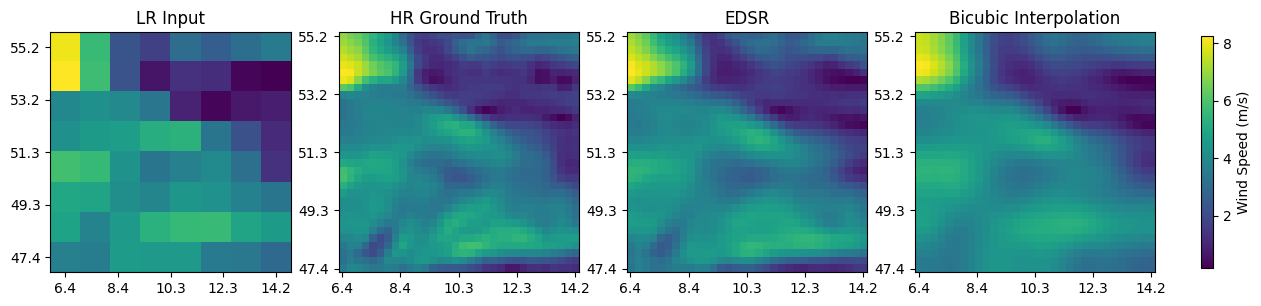

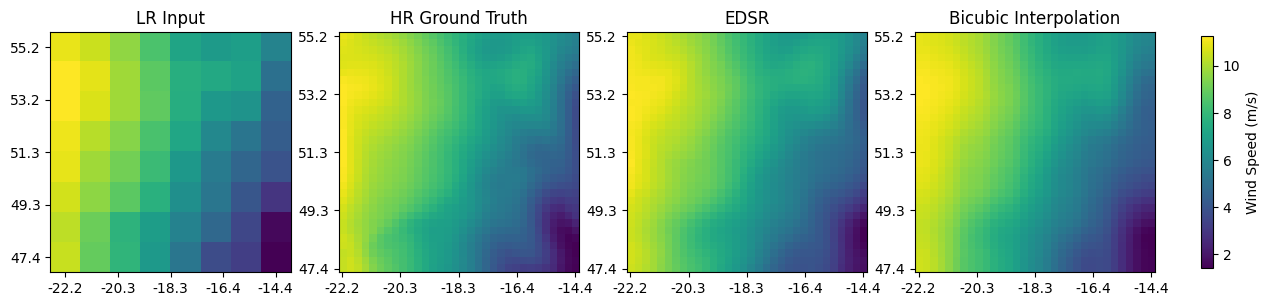

In [43]:
longitudes_de = eval_split_de['longitude'].values
latitudes_de = eval_split_de['latitude'].values
longitudes_atl = eval_split_atl['longitude'].values
latitudes_atl = eval_split_atl['latitude'].values
index = np.random.randint(0, len(ground_truth_ws_de))
 
plot_comparison(ws_fields_de, names_de, index, longitudes_de, latitudes_de)
plot_comparison(ws_fields_atl, names_atl, index, longitudes_atl, latitudes_atl)

In [44]:
ws_dict = {year: {} for year in years}
preds_dir_atlantic = '../../preds_atlantic/'
for year in years:
        eval_split_de, ground_truth_ws_de, scale_de = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        eval_split_atl, ground_truth_ws_atl, scale_atl = get_ground_truth_ws(data_dir=dataset_dir_atlantic,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        
        lr_ws_de = get_low_res_ws(eval_split_de, SCALING_FACTOR)
        lr_ws_atl = get_low_res_ws(eval_split_atl, SCALING_FACTOR)
        ws_fields_de, names_de = get_wind_speed_fields_de(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale_de, 
                                                lr_ws=lr_ws_de, 
                                                gt_ws=ground_truth_ws_de)
        ws_fields_atl, names_atl = get_wind_speed_fields_atl(files_dir=preds_dir_atlantic,
                                                scaling_factor=SCALING_FACTOR,
                                                year=year,
                                                normalization_scale=scale_atl,
                                                lr_ws=lr_ws_atl,
                                                gt_ws=ground_truth_ws_atl)
        
        edsr_de = ws_fields_de[names_de.index('EDSR')]
        baseline_de = ws_fields_de[names_de.index('Bicubic Interpolation')]
        ground_truth_ws_de = ws_fields_de[names_de.index('HR Ground Truth')]

        edsr_atl = ws_fields_atl[names_atl.index('EDSR')]
        baseline_atl = ws_fields_atl[names_atl.index('Bicubic Interpolation')]
        ground_truth_ws_atl = ws_fields_atl[names_atl.index('HR Ground Truth')]
        ws_dict[year]['EDSR_de'] = edsr_de
        ws_dict[year]['Baseline_de'] = baseline_de
        ws_dict[year]['Ground Truth_de'] = ground_truth_ws_de
        ws_dict[year]['EDSR_atl'] = edsr_atl
        ws_dict[year]['Baseline_atl'] = baseline_atl
        ws_dict[year]['Ground Truth_atl'] = ground_truth_ws_atl

In [45]:
def get_metrics_over_time(years):
    mses = {'EDSR_de': [], 'Bicubic_de': [], 'EDSR_atl': [], 'Bicubic_atl': []}
    maes = {'EDSR_de': [], 'Bicubic_de': [], 'EDSR_atl': [], 'Bicubic_atl': []}
    mse_skill_scores = {'EDSR_de': [], 'Bicubic_de': [], 'EDSR_atl': [], 'Bicubic_atl': []}
    mae_skill_scores = {'EDSR_de': [], 'Bicubic_de': [], 'EDSR_atl': [], 'Bicubic_atl': []}
    for year in years:
        edsr_de, baseline_de = ws_dict[year]['EDSR_de'], ws_dict[year]['Baseline_de']
        edsr_atl, baseline_atl = ws_dict[year]['EDSR_atl'], ws_dict[year]['Baseline_atl']
        ground_truth_ws_de = ws_dict[year]['Ground Truth_de']
        ground_truth_ws_atl = ws_dict[year]['Ground Truth_atl']        
        mse_edsr_de, mae_edsr_de = get_metrics(edsr_de, ground_truth_ws_de)
        mse_baseline_de, mae_baseline_de = get_metrics(baseline_de, ground_truth_ws_de)
        mse_edsr_atl, mae_edsr_atl = get_metrics(edsr_atl, ground_truth_ws_atl)
        mse_baseline_atl, mae_baseline_atl = get_metrics(baseline_atl, ground_truth_ws_atl)
        mse_skill_scores['EDSR_de'].append(get_skill_score(mse_edsr_de, mse_baseline_de))
        mae_skill_scores['EDSR_de'].append(get_skill_score(mae_edsr_de, mae_baseline_de))
        mse_skill_scores['EDSR_atl'].append(get_skill_score(mse_edsr_atl, mse_baseline_atl))
        mae_skill_scores['EDSR_atl'].append(get_skill_score(mae_edsr_atl, mae_baseline_atl))
        
        mses['EDSR_de'].append(mse_edsr_de)
        mses['Bicubic_de'].append(mse_baseline_de)
        mses['EDSR_atl'].append(mse_edsr_atl)
        mses['Bicubic_atl'].append(mse_baseline_atl)
        maes['EDSR_de'].append(mae_edsr_de)
        maes['Bicubic_de'].append(mae_baseline_de)
        maes['EDSR_atl'].append(mae_edsr_atl)
        maes['Bicubic_atl'].append(mae_baseline_atl)
        
    return mses, maes, mse_skill_scores, mae_skill_scores

mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

In [46]:
def plot_metrics(years, mse_north, mse_south, mae_north, mae_south, label_a, label_b):
    fig, ax = plt.subplots(1, 2, figsize=(20, 6))

    ax[0].plot(years, mse_north, label=label_a, color='midnightblue')
    ax[0].plot(years, mse_south, label=label_b, color='lightsteelblue')
    ax[0].set_xlabel('Year', fontsize=16)
    ax[0].set_ylabel('MSE', fontsize=16)
    ax[0].legend(fontsize=14)
    ax[0].grid(True)

    ax[1].plot(years, mae_north, label=label_a, color='darkred')
    ax[1].plot(years, mae_south, label=label_b, color='lightcoral')
    ax[1].set_xlabel('Year', fontsize=16)
    ax[1].set_ylabel('MAE', fontsize=16)
    ax[1].legend(fontsize=14)
    ax[1].grid(True)

    for a in ax:
        a.tick_params(axis='both', labelsize=14)

    plt.tight_layout()
    plt.show()

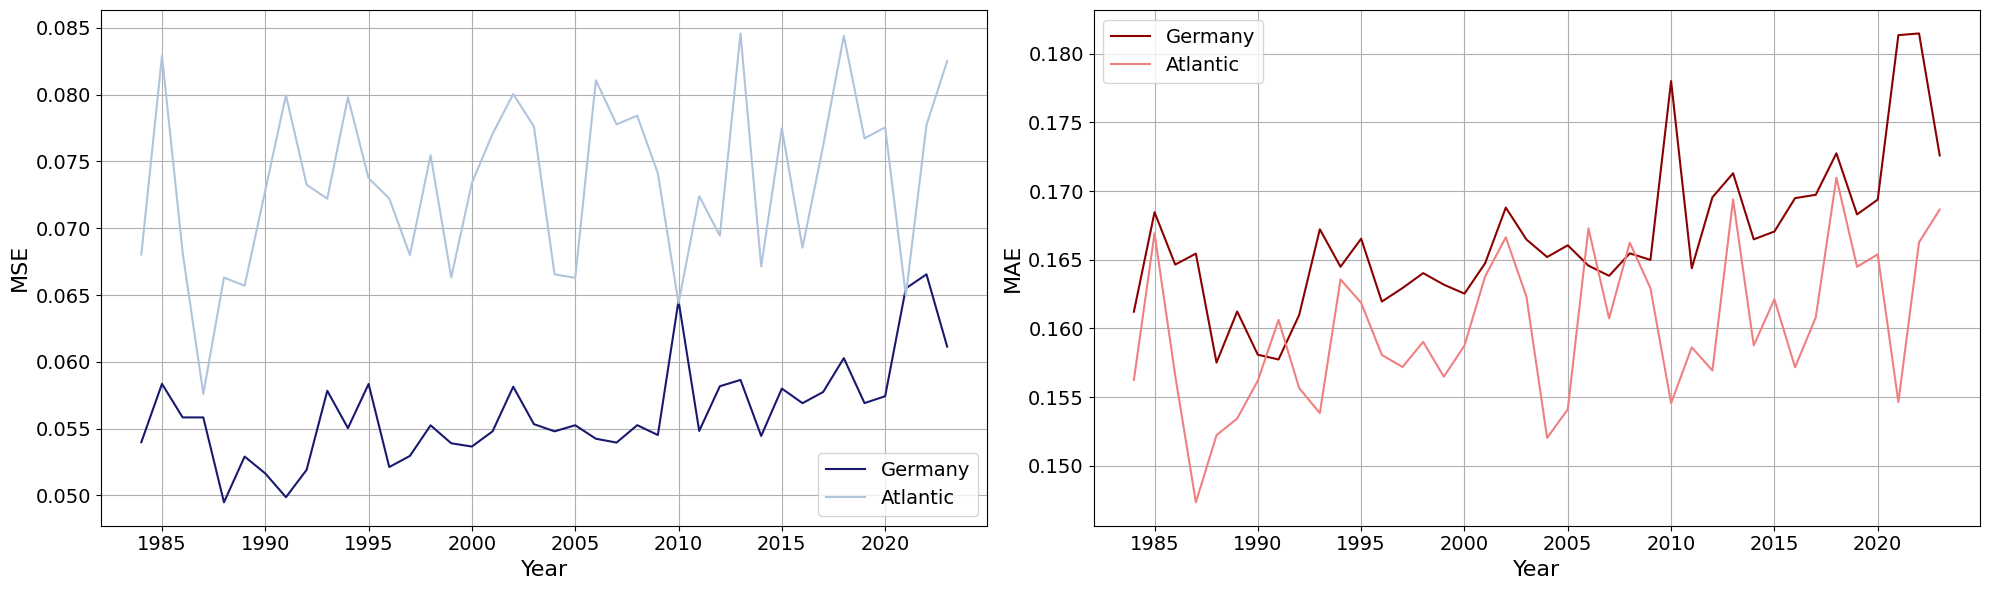

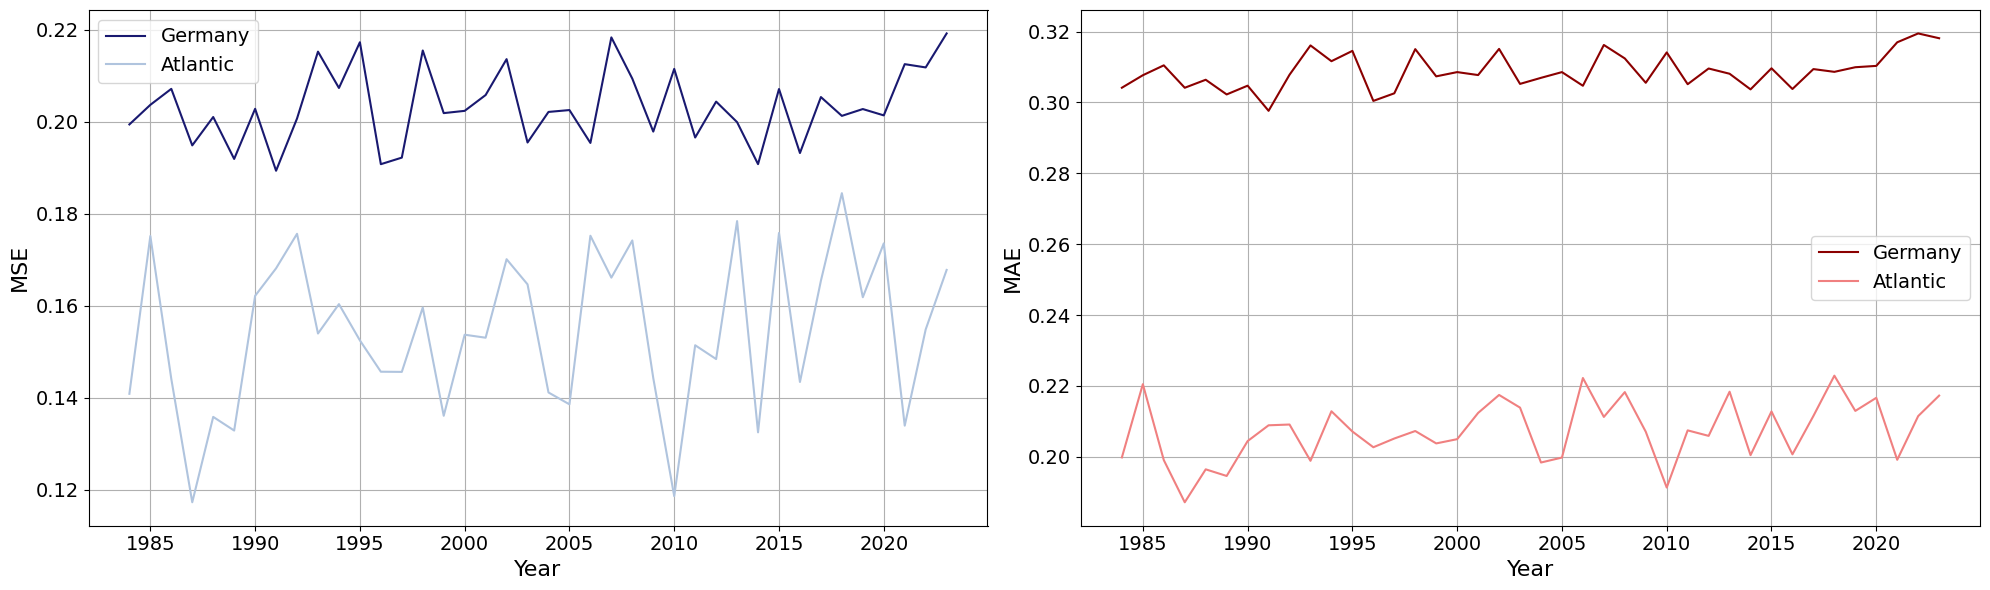

In [47]:
plot_metrics(years, mses['EDSR_de'], mses['EDSR_atl'], maes['EDSR_de'], maes['EDSR_atl'], 'Germany', 'Atlantic')
plot_metrics(years, mses['Bicubic_de'], mses['Bicubic_atl'], maes['Bicubic_de'], maes['Bicubic_atl'], 'Germany', 'Atlantic')

In [48]:
from scipy.stats import linregress

Atlantic
Slope: 0.000154, 
Intercept: -0.235907, 
R-value: 0.283017, 
P-value: 0.07679764, 
Std. Error: 0.000085


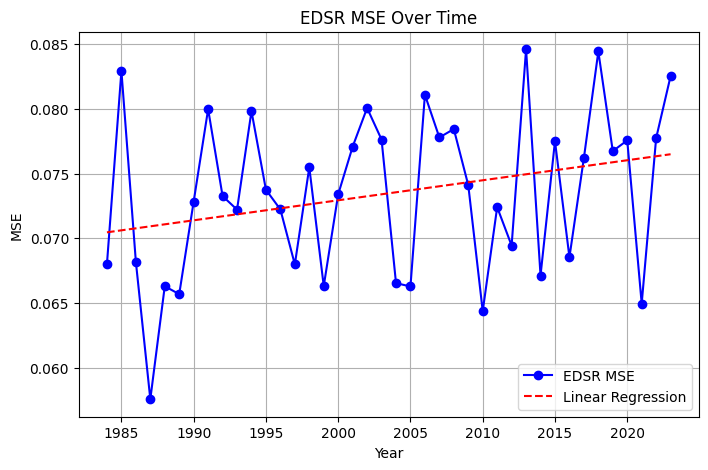

Germany
Slope: 0.000195, 
Intercept: -0.334513, 
R-value: 0.610770, 
P-value: 0.00002845, 
Std. Error: 0.000041


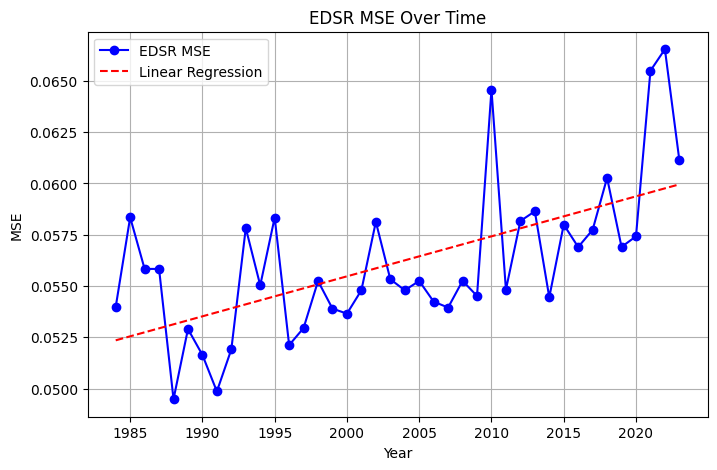

In [49]:
res = linregress(years, mses['EDSR_atl'])
slope, intercept, r_value, p_value, std_err = res
print('Atlantic')
print(f"Slope: {slope:.6f}, \nIntercept: {intercept:.6f}, \nR-value: {r_value:.6f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mses['EDSR_atl'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

res = linregress(years, mses['EDSR_de'])
slope, intercept, r_value, p_value, std_err = res
print('Germany')
print(f"Slope: {slope:.6f}, \nIntercept: {intercept:.6f}, \nR-value: {r_value:.6f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mses['EDSR_de'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

Atlantic
Slope: 0.000214, 
Intercept: -0.269045, 
R-value: 0.456558, 
P-value: 0.00306409, 
Std. Error: 0.000068


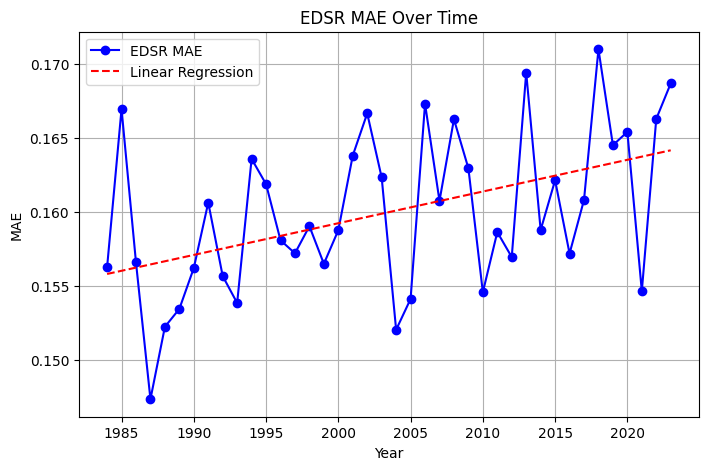

Germany
Slope: 0.000327, 
Intercept: -0.488532, 
R-value: 0.706705, 
P-value: 0.00000035, 
Std. Error: 0.000053


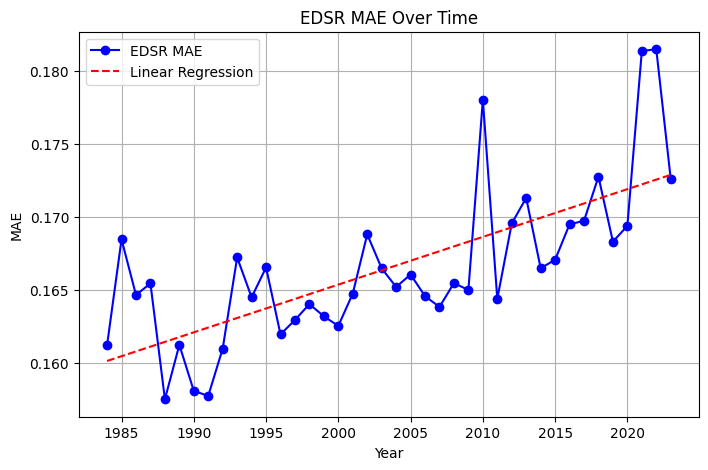

In [50]:
res = linregress(years, maes['EDSR_atl'])
slope, intercept, r_value, p_value, std_err = res
print('Atlantic')
print(f"Slope: {slope:.6f}, \nIntercept: {intercept:.6f}, \nR-value: {r_value:.6f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, maes['EDSR_atl'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

res = linregress(years, maes['EDSR_de'])
slope, intercept, r_value, p_value, std_err = res
print('Germany')
print(f"Slope: {slope:.6f}, \nIntercept: {intercept:.6f}, \nR-value: {r_value:.6f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.6f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, maes['EDSR_de'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()
